# Entrega 2: Simulación e inferencia — Airbnb Nueva York

**Estadística Computacional (INF280), Universidad Técnica Federico Santa María**  
**Grupo 17:** José Flores, Sebastian Alcaide, Pedro Ortiz y Miguel Primera  
**Tutor:** Cristobal Duarte  
**Dataset:** [Airbnb Open Data (NYC)](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata), versión 1.

## Objetivo
Estimar las calificaciones medias de Manhattan y Brooklyn, cuantificar la incertidumbre de su diferencia y estudiar mediante simulación cómo el tamaño muestral afecta la capacidad de detectar una diferencia pequeña.

| Requisito de LEC2 | Sección |
|---|---|
| Parámetros vinculados a la Entrega 1 y estimación puntual | 2 y 3 |
| Origen, explicación e implementación propia de bootstrap | 4 |
| Distribuciones, comparación y estabilidad de bootstrap | 4 y 5 |
| Modelo, implementación e interpretación de Monte Carlo | 6 y 7 |
| Conclusiones, límites y reproducibilidad | 8 y 9 |

**Uso de IA en esta entrega:** ChatGPT/Codex apoyó la definición del análisis, la programación, las verificaciones y la redacción inicial. Cada integrante debe revisar y comprender el código y las interpretaciones antes de presentar. La declaración de Claude/Gemini de la Entrega 1 corresponde a aquella entrega.


## 1. Reproducibilidad y continuidad de la limpieza

Este notebook funciona de forma independiente. Incluimos el CSV original en `data/`, por lo que la ejecución del paquete no necesita acceso a Kaggle. Si falta, se busca una copia local o se descarga **la versión 1** con `kagglehub`. No se utiliza una submuestra ni se reutiliza un kernel de la Entrega 1.

La limpieza conserva sus decisiones: eliminar duplicados exactos, corregir dos nombres de distrito, convertir las columnas monetarias, normalizar nombres, descartar cuatro columnas y sustituir valores físicamente imposibles por `NaN`. No imputamos calificaciones. Las exclusiones para el análisis se hacen solo en las columnas necesarias.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

SEED_BOOT = 20261004
SEED_MC = 20261005
B = 20000                        # réplicas bootstrap
R = 20000                        # realizaciones Monte Carlo por escenario
ALPHA = 0.05
TOL_PRECISION = 0.05              # precisión deseada, en puntos de calificación
UMBRALES = [0.05, 0.10, 0.20]     # referencias exploratorias de magnitud
SHA_ESPERADO = 'ecb59a7598d2aaf7dc2ed00c724648a319d93a916a3d4767e2bed0dbe0f1a7f8'

# Funciona tanto desde entrega2/ como desde la raíz del repositorio.
BASE = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd() / 'entrega2'
if not BASE.exists():
    BASE = Path.cwd()
OUT = BASE / 'resultados'
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
COLOR_M, COLOR_B = '#087e8b', '#c85a43'
pd.set_option('display.precision', 6)

versiones = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scipy': scipy.__version__,
            'matplotlib': matplotlib.__version__}
display(pd.Series(versiones, name='versión'))


python        3.14.7
numpy          2.5.3
pandas         3.0.5
scipy         1.18.1
matplotlib    3.11.2
Name: versión, dtype: str

In [2]:
candidatos = [BASE / 'data' / 'Airbnb_Open_Data.csv',
              Path.cwd() / 'Airbnb_Open_Data.csv',
              Path.home() / '.cache' / 'kagglehub' / 'datasets' /
              'arianazmoudeh' / 'airbnbopendata' / 'versions' / '1' /
              'Airbnb_Open_Data.csv']
CSV = next((p for p in candidatos if p.is_file()), None)
if CSV is None:
    import kagglehub
    descargado = Path(kagglehub.dataset_download('arianazmoudeh/airbnbopendata/versions/1'))
    CSV = descargado / 'Airbnb_Open_Data.csv'
sha256 = hashlib.sha256(CSV.read_bytes()).hexdigest()
if sha256 != SHA_ESPERADO:
    raise ValueError('El CSV no coincide con la versión analizada. Usar data/Airbnb_Open_Data.csv del paquete.')
raw = pd.read_csv(CSV, low_memory=False)
print('Dataset:', CSV.name)
print('Dimensiones originales:', raw.shape)
print('SHA-256:', sha256)

def limpiar_entrega1(datos):
    """Reproduce las decisiones de limpieza de la Entrega 1."""
    d = datos.drop_duplicates().copy()
    d.columns = d.columns.str.strip().str.lower().str.replace(' ', '_', regex=False)
    d['neighbourhood_group'] = d['neighbourhood_group'].replace(
        {'manhatan': 'Manhattan', 'brookln': 'Brooklyn'})
    for col in ['price', 'service_fee']:
        texto = d[col].astype('string').str.replace('$', '', regex=False)
        texto = texto.str.replace(',', '', regex=False).str.strip()
        d[col] = pd.to_numeric(texto, errors='coerce')
    d = d.drop(columns=['license', 'house_rules', 'country', 'country_code'])
    inv_a = ~d['availability_365'].between(0, 365) & d['availability_365'].notna()
    inv_n = d['minimum_nights'] < 0
    auditoria = {'filas_originales': len(datos),
                 'duplicados_eliminados': len(datos) - len(d),
                 'disponibilidad_invalida': int(inv_a.sum()),
                 'noches_negativas': int(inv_n.sum()),
                 'filas_limpias': len(d), 'columnas_limpias': d.shape[1]}
    d.loc[inv_a, 'availability_365'] = np.nan
    d.loc[inv_n, 'minimum_nights'] = np.nan
    return d, auditoria

df, auditoria = limpiar_entrega1(raw)
assert raw.shape == (102599, 26), 'La versión de los datos no coincide con la Entrega 1.'
assert df.shape == (102058, 22)
assert auditoria['duplicados_eliminados'] == 541
assert auditoria['disponibilidad_invalida'] == 3185
assert auditoria['noches_negativas'] == 13
display(pd.Series(auditoria, name='auditoría'))


Dataset: Airbnb_Open_Data.csv
Dimensiones originales: (102599, 26)
SHA-256: ecb59a7598d2aaf7dc2ed00c724648a319d93a916a3d4767e2bed0dbe0f1a7f8


filas_originales           102599
duplicados_eliminados         541
disponibilidad_invalida      3185
noches_negativas               13
filas_limpias              102058
columnas_limpias               22
Name: auditoría, dtype: int64

In [3]:
pares = df[['neighbourhood_group', 'review_rate_number']].dropna().copy()
assert pares['review_rate_number'].isin([1, 2, 3, 4, 5]).all()
assert len(pares) == 101712
resumen_distritos = pares.groupby('neighbourhood_group')['review_rate_number'].agg(
    n='size', media='mean', desviacion='std')
resumen_distritos['EE_media'] = resumen_distritos['desviacion'] / np.sqrt(resumen_distritos['n'])
display(resumen_distritos)
print('Filas excluidas por falta de distrito o calificación:', len(df) - len(pares))

seleccion = pares[pares['neighbourhood_group'].isin(['Manhattan', 'Brooklyn'])]
M = seleccion.loc[seleccion['neighbourhood_group'].eq('Manhattan'), 'review_rate_number'].to_numpy()
K = seleccion.loc[seleccion['neighbourhood_group'].eq('Brooklyn'), 'review_rate_number'].to_numpy()
assert (len(M), len(K)) == (43418, 41515)
control_hosts = df.loc[seleccion.index, 'host_id']
print('Pares utilizados:', len(seleccion))
print('IDs de anfitrión repetidos en el subconjunto:', int(control_hosts.duplicated().sum()))


Filas excluidas por falta de distrito o calificación: 346
Pares utilizados: 84933
IDs de anfitrión repetidos en el subconjunto: 0


,n,media,desviacion,EE_media
neighbourhood_group,,,,
Bronx,2677,3.331341,1.212648,0.023437
Brooklyn,41515,3.258461,1.295044,0.006356
Manhattan,43418,3.276521,1.290677,0.006194
Queens,13159,3.330420,1.248600,0.010885
Staten Island,943,3.404030,1.255588,0.040888


## 2. Pregunta, población de referencia y parámetros

La Entrega 1 preguntó si las calificaciones variaban entre los cinco distritos. Esta entrega cuantifica un contraste específico dentro de esa pregunta: **¿cuánto difieren las calificaciones medias de los anuncios de Manhattan y Brooklyn, y con qué precisión podemos estimarlas?** Elegimos estos distritos por su tamaño y peso en la oferta registrada, sin seleccionar el mayor y el menor promedio observado. El contraste no responde por sí solo a la comparación global de los cinco distritos.

Seleccionamos **dos parámetros poblacionales**:

$$
\mu_M=E(Y\mid D=\text{Manhattan}),\qquad
\mu_B=E(Y\mid D=\text{Brooklyn}).
$$

Su contraste derivado es $\Delta=\mu_M-\mu_B$, medido en **puntos de calificación**. $\Delta>0$ representa una media mayor en Manhattan. Los estimadores son $\bar Y_M$, $\bar Y_B$ y $\widehat\Delta=\bar Y_M-\bar Y_B$.

**Unidad de análisis:** un anuncio con calificación y distrito observados. Cada anuncio pesa lo mismo. No disponemos de las calificaciones individuales de huéspedes, por lo que no estimamos una media por huésped ni ponderamos por cantidad de reseñas.

**Alcance poblacional:** la inferencia describe un modelo de anuncios comparables a los registrados en esta fuente, condicionado a tener calificación disponible. El dataset no documenta un muestreo probabilístico del mercado de NYC. Interpretamos los intervalos como incertidumbre bajo el modelo de muestreo adoptado. Si los anuncios registrados fueran toda la población de interés, sus medias serían descriptivas exactas y no necesitarían intervalos por muestreo.

**Supuestos:** anuncios independientes dentro de cada distrito y entre distritos, con distribución estable y varianza finita. Los IDs de anfitrión no se repiten en el subconjunto elegido, pero eso no garantiza independencia espacial o temporal. La escala 1–5 es ordinal. El uso de medias supone que sus distancias numéricas son comparables, de modo que el resultado debe leerse como una media de puntuaciones codificadas.


## 3. Estimación puntual clásica y propiedades

Para cada distrito $g$, usamos:

$$
\widehat\mu_g=\bar Y_g=\frac{1}{n_g}\sum_iY_{gi},\qquad
\widehat{EE}(\bar Y_g)=\frac{s_g}{\sqrt{n_g}}.
$$

Para el contraste entre muestras independientes:

$$
\widehat\Delta=\bar Y_M-\bar Y_B,\qquad
\widehat{EE}(\widehat\Delta)=\sqrt{\frac{s_M^2}{n_M}+\frac{s_B^2}{n_B}}.
$$

Además de la estimación puntual solicitada, incluimos IC del 95% como apoyo: $\widehat\theta\pm t_{0.975,\nu}\widehat{EE}$. En las medias usamos $\nu=n_g-1$. En la diferencia usamos los grados de libertad de Welch:

$$
\nu=\frac{(s_M^2/n_M+s_B^2/n_B)^2}
{(s_M^2/n_M)^2/(n_M-1)+(s_B^2/n_B)^2/(n_B-1)}.
$$

La distribución de las puntuaciones no es normal. Por ello, estos intervalos t son **aproximaciones de muestra grande**, respaldadas por la distribución asintótica de las medias.

- **Sesgo:** bajo los supuestos anteriores, $E(\bar Y_g)=\mu_g$ y $E(\widehat\Delta)=\Delta$. Son insesgados bajo el modelo, sin que esto elimine sesgos de selección o de datos faltantes.
- **Consistencia:** por la ley de los grandes números, las medias convergen a sus parámetros cuando crecen los tamaños de ambos grupos. Las puntuaciones están acotadas, por lo que la varianza es finita.
- **Eficiencia:** la media tiene varianza $\sigma_g^2/n_g$ y minimiza la varianza entre estimadores lineales insesgados con observaciones independientes de igual varianza dentro del grupo. No afirmamos eficiencia universal entre todos los estimadores o diseños.


In [4]:
def intervalo_media(x, alpha=ALPHA):
    n = len(x)
    estimacion = float(np.mean(x))
    ee = float(np.std(x, ddof=1) / np.sqrt(n))
    q = stats.t.ppf(1 - alpha / 2, n - 1)
    return estimacion, ee, estimacion - q * ee, estimacion + q * ee

def intervalo_diferencia(x, y, alpha=ALPHA):
    a = np.var(x, ddof=1) / len(x)
    b = np.var(y, ddof=1) / len(y)
    ee = float(np.sqrt(a + b))
    nu = (a + b)**2 / (a**2 / (len(x)-1) + b**2 / (len(y)-1))
    estimacion = float(np.mean(x) - np.mean(y))
    q = stats.t.ppf(1 - alpha / 2, nu)
    return estimacion, ee, estimacion - q * ee, estimacion + q * ee, float(nu)

mu_m, ee_m, lo_m, hi_m = intervalo_media(M)
mu_b, ee_b, lo_b, hi_b = intervalo_media(K)
delta, ee_delta, lo_delta, hi_delta, nu_delta = intervalo_diferencia(M, K)
clasica = pd.DataFrame([
    ['Media Manhattan', len(M), mu_m, ee_m, lo_m, hi_m],
    ['Media Brooklyn', len(K), mu_b, ee_b, lo_b, hi_b],
    ['Diferencia M − B', len(M)+len(K), delta, ee_delta, lo_delta, hi_delta]],
    columns=['estimador', 'n', 'estimacion', 'EE_clasico', 'IC95_inf', 'IC95_sup']).set_index('estimador')
display(clasica)
display(Markdown(f'**Resultado puntual:** Manhattan: {mu_m:.4f}; Brooklyn: {mu_b:.4f}. '
                 f'La diferencia es **{delta:.4f} puntos**, con IC clásico del 95% '
                 f'[{lo_delta:.4f}, {hi_delta:.4f}].'))


,n,estimacion,EE_clasico,IC95_inf,IC95_sup
estimador,,,,,
Media Manhattan,43418,3.276521,0.006194,3.264381,3.288662
Media Brooklyn,41515,3.258461,0.006356,3.246003,3.270919
Diferencia M − B,84933,0.018060,0.008875,0.000665,0.035455


**Resultado puntual:** Manhattan: 3.2765; Brooklyn: 3.2585. La diferencia es **0.0181 puntos**, con IC clásico del 95% [0.0007, 0.0355].

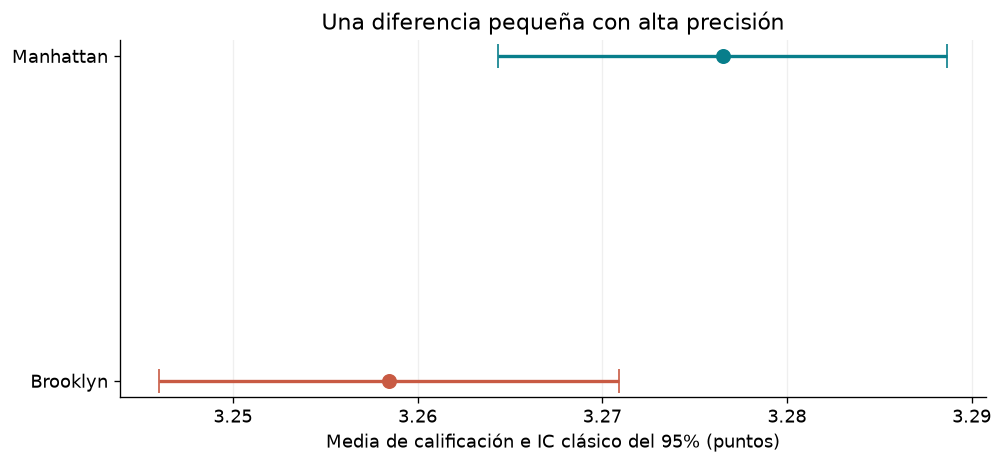

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4))
for j, (nombre, media, lo, hi, color) in enumerate([
        ('Brooklyn', mu_b, lo_b, hi_b, COLOR_B),
        ('Manhattan', mu_m, lo_m, hi_m, COLOR_M)]):
    ax.errorbar(media, j, xerr=[[media-lo], [hi-media]], fmt='o',
                color=color, capsize=7, markersize=8, linewidth=2)
ax.set_yticks([0, 1], ['Brooklyn', 'Manhattan'])
ax.set_xlabel('Media de calificación e IC clásico del 95% (puntos)')
ax.set_title('Una diferencia pequeña con alta precisión')
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
fig.savefig(OUT / '01_medias_ic.png', dpi=180)
plt.show()


## 4. Bootstrap: fundamento e implementación propia

### 4.1 Origen y motivación

Bradley Efron presentó el bootstrap en 1979 en *Bootstrap Methods: Another Look at the Jackknife* [1]. El método aproxima la distribución muestral de un estadístico utilizando la distribución empírica de los datos. Es útil cuando resulta difícil derivar analíticamente su incertidumbre. En este trabajo sirve también como comparación computacional con las fórmulas de la media.

### 4.2 Procedimiento

1. Calcular las medias y su diferencia en las muestras observadas.
2. Sortear **con reemplazo** $n_M$ índices de Manhattan y, de forma independiente, $n_B$ de Brooklyn. Cada registro tiene probabilidad $1/n_g$ dentro de su distrito.
3. Calcular $\bar Y_M^*$, $\bar Y_B^*$ y $\widehat\Delta^*=\bar Y_M^*-\bar Y_B^*$.
4. Repetir el procedimiento $B=20.000$ veces.
5. Usar la desviación estándar de las réplicas como EE bootstrap y sus percentiles 2,5 y 97,5 como IC percentil.

El remuestreo mantiene los tamaños de cada distrito. **Una réplica bootstrap conserva el tamaño original**, aunque algunos anuncios se repitan y otros no aparezcan. Remuestrear no añade información nueva ni corrige automáticamente problemas de representatividad.

La siguiente función usa NumPy para sortear índices y calcular medias. **No utiliza `scipy.stats.bootstrap`, `sklearn.utils.resample` ni otra implementación directa de bootstrap.** Los lotes limitan memoria sin alterar el procedimiento.


In [6]:
def bootstrap_medias(x, y, replicas=20000, seed=20261004, lote=16):
    """Bootstrap no paramétrico independiente dentro de cada distrito.

    Devuelve una fila por réplica y columnas [media_x, media_y, diferencia].
    El parámetro lote controla memoria, no el tamaño de las remuestras.
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    if x.ndim != 1 or y.ndim != 1 or min(len(x), len(y)) < 2:
        raise ValueError('Se requieren dos vectores con al menos dos datos.')
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError('Resolver los datos faltantes antes del remuestreo.')
    if replicas < 2 or lote < 1:
        raise ValueError('replicas >= 2 y lote >= 1.')
    # Flujos independientes: un distrito no afecta los sorteos del otro.
    semillas = np.random.SeedSequence(seed).spawn(2)
    rng_x, rng_y = [np.random.default_rng(s) for s in semillas]
    resultado = np.empty((replicas, 3), dtype=float)
    for inicio in range(0, replicas, lote):
        fin = min(inicio + lote, replicas)
        indices_x = rng_x.integers(0, len(x), size=(fin-inicio, len(x)))
        resultado[inicio:fin, 0] = x[indices_x].mean(axis=1)
        indices_y = rng_y.integers(0, len(y), size=(fin-inicio, len(y)))
        resultado[inicio:fin, 1] = y[indices_y].mean(axis=1)
    resultado[:, 2] = resultado[:, 0] - resultado[:, 1]
    return resultado

boot = bootstrap_medias(M, K, replicas=B, seed=SEED_BOOT)
boot_tabla = pd.DataFrame({
    'promedio_replicas': boot.mean(axis=0),
    'sesgo_boot_estimado': boot.mean(axis=0) - clasica['estimacion'].to_numpy(),
    'EE_boot': boot.std(axis=0, ddof=1),
    'IC95_boot_inf': np.quantile(boot, 0.025, axis=0),
    'IC95_boot_sup': np.quantile(boot, 0.975, axis=0)}, index=clasica.index)
display(boot_tabla)


,promedio_replicas,sesgo_boot_estimado,EE_boot,IC95_boot_inf,IC95_boot_sup
estimador,,,,,
Media Manhattan,3.276553,0.000032,0.006239,3.264383,3.288866
Media Brooklyn,3.258452,-0.000009,0.006325,3.246127,3.270746
Diferencia M − B,0.018101,0.000040,0.008844,0.000550,0.035416


### 4.3 Qué significan los resultados bootstrap

El **estimador puntual principal** sigue siendo la media observada o la diferencia observada. El promedio de las réplicas es una comprobación de centrado, no un estimador necesariamente mejor. La cantidad $\overline{\widehat\theta^*}-\widehat\theta$ estima el sesgo bajo la distribución empírica.

Para la media, $E^*(\bar Y_g^*)=\bar Y_g$ exactamente. El sesgo bootstrap teórico es cero y el pequeño sesgo numérico procede de usar un número finito de réplicas. Además,

$$
\operatorname{Var}^*(\bar Y_g^*)=\frac{n_g-1}{n_g}\frac{s_g^2}{n_g}.
$$

Esta identidad permite contrastar nuestra simulación con una referencia analítica. El bootstrap describe variación bajo la distribución empírica [2]. Un IC del 95% se refiere a la cobertura del procedimiento en muestreos repetidos, **no** a una probabilidad posterior del 95% sobre el parámetro fijo.


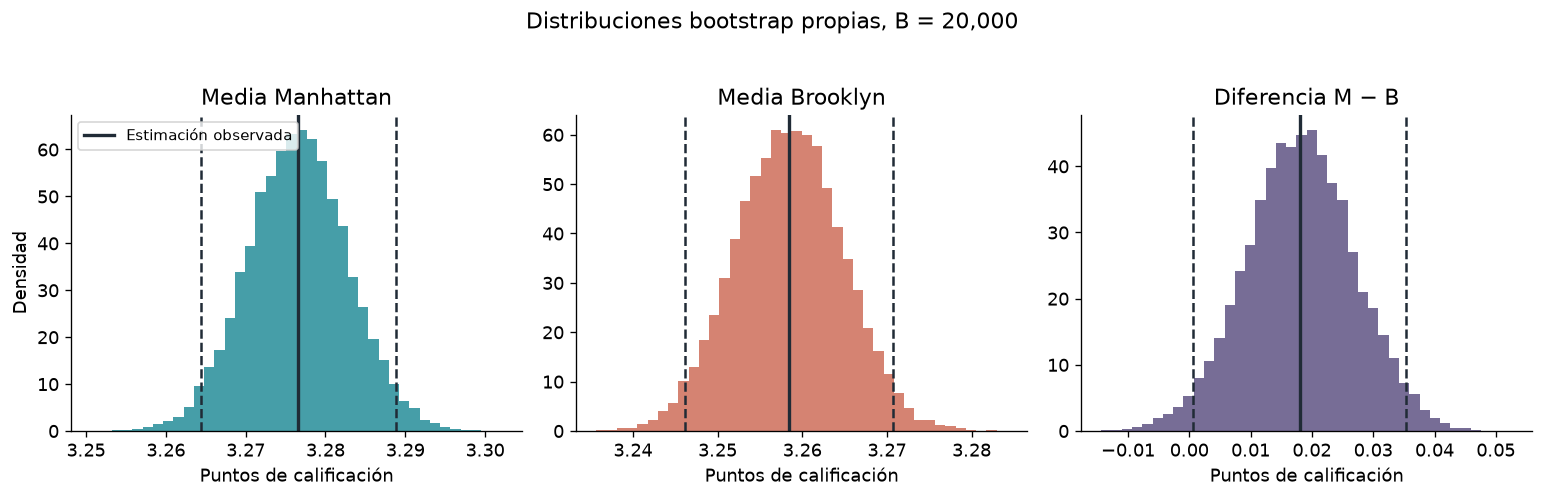

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for j, (ax, nombre, color) in enumerate(zip(axes, clasica.index, [COLOR_M, COLOR_B, '#493c73'])):
    ax.hist(boot[:, j], bins=40, density=True, color=color, alpha=0.75)
    ax.axvline(clasica.iloc[j]['estimacion'], color='#202b36', linewidth=2,
               label='Estimación observada')
    for q in [0.025, 0.975]:
        ax.axvline(np.quantile(boot[:, j], q), color='#202b36', linestyle='--')
    ax.set_title(nombre)
    ax.set_xlabel('Puntos de calificación')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)
fig.suptitle(f'Distribuciones bootstrap propias, B = {B:,}', y=1.03)
fig.tight_layout()
fig.savefig(OUT / '02_bootstrap_distribuciones.png', dpi=180, bbox_inches='tight')
plt.show()


In [8]:
filas_estabilidad = []
for b in [500, 2500, 5000, 10000, B]:
    v = boot[:b, 2]
    filas_estabilidad.append([b, v.mean(), v.std(ddof=1),
                             *np.quantile(v, [0.025, 0.975])])
estabilidad_boot = pd.DataFrame(filas_estabilidad,
    columns=['B', 'promedio_delta', 'EE_delta', 'IC95_inf', 'IC95_sup'])
display(estabilidad_boot)

# Referencia exacta condicional para el bootstrap de estas medias.
ee_boot_exactos = np.array([
    np.sqrt((len(M)-1)/len(M)) * ee_m,
    np.sqrt((len(K)-1)/len(K)) * ee_b,
    np.sqrt((len(M)-1)/len(M)*ee_m**2 + (len(K)-1)/len(K)*ee_b**2)])
check_boot = pd.DataFrame({'EE_boot_simulado': boot.std(axis=0, ddof=1),
    'EE_boot_teorico': ee_boot_exactos}, index=clasica.index)
check_boot['error_relativo'] = check_boot['EE_boot_simulado'] / check_boot['EE_boot_teorico'] - 1
display(check_boot)
display(Markdown(f'Con {B:,} réplicas, el EE bootstrap de la diferencia es '
                 f'{boot[:,2].std(ddof=1):.6f}, frente a {ee_boot_exactos[2]:.6f} '
                 f'como referencia condicional exacta. La tabla muestra la estabilidad '
                 f'al aumentar B. Más réplicas reducen el error de simulación, '
                 f'pero no el error asociado al tamaño de la muestra original.'))


,B,promedio_delta,EE_delta,IC95_inf,IC95_sup
0,500,0.017686,0.008832,-0.000635,0.034765
1,2500,0.018007,0.008914,-0.000063,0.035203
2,5000,0.018078,0.008798,0.000661,0.035351
3,10000,0.018123,0.008860,0.000446,0.035433
4,20000,0.018101,0.008844,0.000550,0.035416


,EE_boot_simulado,EE_boot_teorico,error_relativo
estimador,,,
Media Manhattan,0.006239,0.006194,0.007206
Media Brooklyn,0.006325,0.006356,-0.004910
Diferencia M − B,0.008844,0.008875,-0.003499


Con 20,000 réplicas, el EE bootstrap de la diferencia es 0.008844, frente a 0.008875 como referencia condicional exacta. La tabla muestra la estabilidad al aumentar B. Más réplicas reducen el error de simulación, pero no el error asociado al tamaño de la muestra original.

## 5. Comparación clásica y bootstrap

Comparamos el mismo estimador, el mismo subconjunto y la misma unidad de medida. El EE clásico usa una fórmula para medias independientes. El bootstrap reproduce la variación del estadístico mediante remuestras. Esperamos similitud porque el estimador es una media y los tamaños de muestra son grandes.

El bootstrap aporta una distribución visible y se puede extender a estadísticos con fórmulas menos simples. Aquí no sustituye la verificación de supuestos. Sus límites incluyen error numérico por $B$ finito, dependencia no modelada, datos ausentes y cobertura aproximada del IC percentil.


In [9]:
comparacion = clasica.join(boot_tabla)
comparacion['razon_EE_boot_clasico'] = comparacion['EE_boot'] / comparacion['EE_clasico']
display(comparacion)
boot_lo, boot_hi = np.quantile(boot[:, 2], [0.025, 0.975])
display(Markdown(f'La diferencia observada es **{delta:.4f} puntos**. '
    f'El IC clásico es [{lo_delta:.4f}, {hi_delta:.4f}] y el bootstrap es '
    f'[{boot_lo:.4f}, {boot_hi:.4f}]. La razón de errores estándar es '
    f'**{boot[:,2].std(ddof=1)/ee_delta:.3f}**. '
    'La concordancia refleja los supuestos y el gran tamaño muestral compartidos. '
    'El límite inferior queda cerca de cero. Las réplicas parciales de la tabla '
    'de estabilidad pueden cambiar su signo, por lo que evitamos conclusiones '
    'fuertes basadas solo en superar un corte de significancia.'))

sensibilidad = pd.DataFrame({'umbral_puntos': UMBRALES,
    'diferencia_observada_menor': [abs(delta) < u for u in UMBRALES],
    'IC_clasico_dentro_de_mas_menos_umbral': [lo_delta > -u and hi_delta < u for u in UMBRALES],
    'IC_boot_dentro_de_mas_menos_umbral': [boot_lo > -u and boot_hi < u for u in UMBRALES]})
display(sensibilidad)


,n,estimacion,EE_clasico,IC95_inf,IC95_sup,promedio_replicas,sesgo_boot_estimado,EE_boot,IC95_boot_inf,IC95_boot_sup,razon_EE_boot_clasico
estimador,,,,,,,,,,,
Media Manhattan,43418,3.276521,0.006194,3.264381,3.288662,3.276553,0.000032,0.006239,3.264383,3.288866,1.007194
Media Brooklyn,41515,3.258461,0.006356,3.246003,3.270919,3.258452,-0.000009,0.006325,3.246127,3.270746,0.995078
Diferencia M − B,84933,0.018060,0.008875,0.000665,0.035455,0.018101,0.000040,0.008844,0.000550,0.035416,0.996489


La diferencia observada es **0.0181 puntos**. El IC clásico es [0.0007, 0.0355] y el bootstrap es [0.0006, 0.0354]. La razón de errores estándar es **0.996**. La concordancia refleja los supuestos y el gran tamaño muestral compartidos. El límite inferior queda cerca de cero. Las réplicas parciales de la tabla de estabilidad pueden cambiar su signo, por lo que evitamos conclusiones fuertes basadas solo en superar un corte de significancia.

,umbral_puntos,diferencia_observada_menor,IC_clasico_dentro_de_mas_menos_umbral,IC_boot_dentro_de_mas_menos_umbral
0,0.05,True,True,True
1,0.10,True,True,True
2,0.20,True,True,True


**Magnitud e interpretación:** la diferencia se expresa en puntos originales de la escala. Los umbrales 0,05, 0,10 y 0,20 son referencias exploratorias propuestas por el grupo. No son estándares validados de satisfacción ni constituyen una prueba formal de equivalencia. El contraste muestra asociación entre distrito y puntuación registrada. No identifica un efecto causal de la ubicación, pues no controla tipo de alojamiento u otras características.


## 6. Monte Carlo: modelo y situación de interés

### 6.1 Idea general
Monte Carlo aproxima cantidades difíciles de calcular mediante numerosas realizaciones aleatorias de un modelo. Debemos fijar las distribuciones de entrada, los supuestos y el número de realizaciones [3]. En nuestro caso, estudiamos **la estabilidad y la detección de la diferencia de medias cuando cambia el tamaño muestral**.

### 6.2 Modelo informado por los datos
En cada distrito $g$, una puntuación simulada toma valores $1,2,3,4,5$, con probabilidades $p_{gk}$ iguales a sus frecuencias relativas observadas. Este modelo categórico respeta los límites y la naturaleza discreta de la variable. Las probabilidades ajustadas se mantienen fijas durante las simulaciones.

Para $n_g$ anuncios independientes, los conteos de puntuaciones son:

$$
(C_{g1},\ldots,C_{g5})\sim\operatorname{Multinomial}(n_g,p_{g1},\ldots,p_{g5}),
\quad \bar Y_g=\frac{\sum_{k=1}^5 kC_{gk}}{n_g}.
$$

Simular conteos multinomiales equivale a generar las puntuaciones categóricas independientes y contarlas. NumPy suministra el generador aleatorio [4], mientras que el cálculo del estadístico y la comparación entre escenarios son propios.

**Escenarios:** 50, 200, 1.000 y 5.000 anuncios por distrito, además de los tamaños originales. Modelamos dos condiciones:

- **Modelo ajustado:** cada distrito tiene su distribución observada. Su diferencia poblacional dentro del modelo es $\Delta_0=\widehat\Delta$.
- **Modelo nulo de control:** ambos distritos tienen la distribución conjunta ponderada por sus tamaños originales. La diferencia del modelo es cero. Este control permite observar la frecuencia de falsos rechazos bajo igualdad de distribuciones.

Estas realizaciones no son pronósticos de nuevas reservas ni probabilidades de que un parámetro real sea positivo. El modelo no incluye incertidumbre sobre las probabilidades ajustadas, dependencia ni cambios futuros del mercado. Con tamaños originales, la distribución ajustada de la diferencia coincide con el objetivo del bootstrap por filas. El aporte adicional de Monte Carlo es variar los tamaños y construir el escenario nulo.

**Regla de decisión en cada realización:** aplicamos una prueba bilateral de Welch, con $H_0:\mu_M=\mu_B$ frente a $H_1:\mu_M\ne\mu_B$. Calculamos $T=\widehat\Delta/\widehat{EE}(\widehat\Delta)$ y rechazamos si $|T|>t_{1-\alpha/2,\nu}$, usando $\alpha=0,05$ y los grados de libertad definidos en la sección 3. No se supone igualdad de varianzas. La concordancia de nuestras fórmulas con `scipy.stats.ttest_ind(equal_var=False)` se comprueba al final [7].

La potencia del modelo ajustado es **condicional al efecto estimado en esta misma muestra**. Por ello, no constituye una validación externa del hallazgo ni una garantía de potencia para otro estudio.


In [10]:
valores = np.arange(1, 6)
conteos = pd.crosstab(pares['neighbourhood_group'], pares['review_rate_number']).reindex(columns=valores)
prob_m = conteos.loc['Manhattan'].to_numpy(dtype=float) / len(M)
prob_b = conteos.loc['Brooklyn'].to_numpy(dtype=float) / len(K)
prob_comun = (conteos.loc['Manhattan'] + conteos.loc['Brooklyn']).to_numpy(dtype=float) / (len(M)+len(K))
probabilidades = pd.DataFrame({'calificacion': valores, 'p_Manhattan': prob_m,
    'p_Brooklyn': prob_b, 'p_comun_nula': prob_comun})
display(probabilidades)
assert np.isclose(prob_m.sum(), 1) and np.isclose(prob_b.sum(), 1)
assert np.isclose(prob_m @ valores - prob_b @ valores, delta)


,calificacion,p_Manhattan,p_Brooklyn,p_comun_nula
0,1,0.092819,0.096640,0.094686
1,2,0.223709,0.227773,0.225696
2,3,0.228315,0.221101,0.224789
3,4,0.224446,0.229459,0.226896
4,5,0.230711,0.225027,0.227933


In [11]:
def simulacion_mc(n_m, n_b, p_m, p_b, realizaciones, seed, alpha=ALPHA):
    """Simula medias y pruebas de Welch desde dos modelos categóricos."""
    semillas = np.random.SeedSequence(seed).spawn(2)
    rng_m, rng_b = [np.random.default_rng(s) for s in semillas]
    c_m = rng_m.multinomial(n_m, p_m, size=realizaciones)
    c_b = rng_b.multinomial(n_b, p_b, size=realizaciones)
    medias_m = (c_m @ valores) / n_m
    medias_b = (c_b @ valores) / n_b
    # Sumatoria de cuadrados / (n-1): varianza muestral, sin generar filas.
    var_m = ((c_m @ (valores**2)) - n_m*medias_m**2) / (n_m-1)
    var_b = ((c_b @ (valores**2)) - n_b*medias_b**2) / (n_b-1)
    a, b = var_m / n_m, var_b / n_b
    ee = np.sqrt(a+b)
    nu = (a+b)**2 / (a**2/(n_m-1) + b**2/(n_b-1))
    dif = medias_m - medias_b
    critico = stats.t.ppf(1-alpha/2, nu)
    rechazo = np.abs(dif / ee) > critico
    return pd.DataFrame({'delta_sim': dif, 'EE_sim': ee, 'rechazo_H0': rechazo})

def intervalo_wilson(eventos, confianza=0.95):
    """Intervalo binomial para la probabilidad estimada por simulación."""
    eventos = np.asarray(eventos, dtype=bool)
    n = eventos.size
    p = eventos.mean()
    z = stats.norm.ppf((1+confianza)/2)
    den = 1+z*z/n
    centro = (p+z*z/(2*n))/den
    margen = z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    # Garantiza límites [0,1] y evita errores de redondeo en p=0 o p=1.
    return float(p), float(np.sqrt(p*(1-p)/n)), float(min(p, max(0, centro-margen))), float(max(p, min(1, centro+margen)))

escenarios = [(50, 50), (200, 200), (1000, 1000), (5000, 5000), (len(M), len(K))]
simulaciones = {}
filas_mc = []
for j, (n_m, n_b) in enumerate(escenarios):
    etiqueta = str(n_m) if n_m == n_b else 'Original'
    for modelo, p_m, p_b, verdad, desplazamiento in [
        ('Ajustado', prob_m, prob_b, delta, 0),
        ('Nulo', prob_comun, prob_comun, 0.0, 1000)]:
        sim = simulacion_mc(n_m, n_b, p_m, p_b, R, SEED_MC+j+desplazamiento)
        simulaciones[(etiqueta, modelo)] = sim
        potencia, ee_p, lo_p, hi_p = intervalo_wilson(sim['rechazo_H0'])
        signo, _, _, _ = intervalo_wilson(sim['delta_sim'] > 0)
        precision, ee_prec, lo_prec, hi_prec = intervalo_wilson(
            np.abs(sim['delta_sim']-verdad) <= TOL_PRECISION)
        filas_mc.append([etiqueta, modelo, n_m, n_b, sim['delta_sim'].mean(),
            sim['delta_sim'].std(ddof=1), potencia, ee_p, lo_p, hi_p,
            signo, precision, ee_prec, lo_prec, hi_prec])
mc_tabla = pd.DataFrame(filas_mc, columns=['escenario', 'modelo', 'n_M', 'n_B',
    'media_delta', 'DE_delta', 'P_rechazo', 'EE_MC_rechazo', 'IC_MC_rechazo_inf',
    'IC_MC_rechazo_sup', 'P_delta_positiva', 'P_error_hasta_005',
    'EE_MC_precision', 'IC_MC_precision_inf', 'IC_MC_precision_sup'])
display(mc_tabla)


,escenario,modelo,n_M,n_B,media_delta,DE_delta,P_rechazo,EE_MC_rechazo,IC_MC_rechazo_inf,IC_MC_rechazo_sup,P_delta_positiva,P_error_hasta_005,EE_MC_precision,IC_MC_precision_inf,IC_MC_precision_sup
0,50,Ajustado,50,50,0.019149,0.258347,0.04950,0.001534,0.046579,0.052594,0.51885,0.15595,0.002565,0.150988,0.161044
1,50,Nulo,50,50,-0.001416,0.259774,0.05130,0.001560,0.048328,0.054445,0.48375,0.15425,0.002554,0.149311,0.159322
2,200,Ajustado,200,200,0.018619,0.130267,0.05340,0.001590,0.050369,0.056603,0.54600,0.29725,0.003232,0.290955,0.303623
3,200,Nulo,200,200,0.000946,0.130630,0.05400,0.001598,0.050952,0.057219,0.49790,0.30195,0.003246,0.295626,0.308350
4,1000,Ajustado,1000,1000,0.018590,0.057560,0.06040,0.001685,0.057182,0.063787,0.62405,0.61350,0.003443,0.606730,0.620226
5,1000,Nulo,1000,1000,-0.000930,0.057972,0.05010,0.001543,0.047162,0.053211,0.48890,0.61340,0.003443,0.606630,0.620127
6,5000,Ajustado,5000,5000,0.018052,0.025927,0.10845,0.002199,0.104216,0.112835,0.75765,0.94430,0.001622,0.941035,0.947394
7,5000,Nulo,5000,5000,0.000026,0.026164,0.05170,0.001566,0.048716,0.054856,0.50130,0.94530,0.001608,0.942062,0.948367
8,Original,Ajustado,43418,41515,0.018031,0.008853,0.52775,0.003530,0.520826,0.534663,0.98110,1.00000,0.000000,0.999808,1.000000
9,Original,Nulo,43418,41515,-0.000103,0.008804,0.04755,0.001505,0.044687,0.050587,0.49710,1.00000,0.000000,0.999808,1.000000


### 6.3 Número de realizaciones y precisión de Monte Carlo

En cada escenario usamos $R=20.000$. Para una probabilidad estimada mediante eventos independientes,

$$
\widehat{EE}_{MC}=\sqrt{\frac{\widehat p(1-\widehat p)}R},\qquad
EE_{MC}\leq\frac{1}{2\sqrt R}.
$$

El máximo EE es 0,00354, con un margen normal aproximado del 95% de 0,00693, es decir, **0,69 puntos porcentuales**. La tabla usa intervalos Wilson para las probabilidades, que también funcionan cuando la proporción simulada está cerca de cero o uno. Estos intervalos cuantifican error Monte Carlo, no la incertidumbre del modelo ajustado.

Para interpretar el cálculo de Wilson [8], con $z=z_{0.975}$ sus límites son

$$
\frac{\widehat p+z^2/(2R)\ \pm\ z\sqrt{\widehat p(1-\widehat p)/R+z^2/(4R^2)}}{1+z^2/R}.
$$

Si todas las realizaciones cumplen un evento, el EE por sustitución vale cero, pero el límite inferior Wilson sigue siendo menor que uno. Así evitamos confundir ausencia de fallos simulados con certeza.

Además de esta cota previa, verificamos la estabilidad empírica con réplicas acumuladas, comparamos bloques independientes y contrastamos la desviación de la diferencia con su fórmula exacta dentro del modelo categórico.


In [12]:
sim_1000 = simulaciones[('1000', 'Ajustado')]
filas_conv = []
for r in [500, 1000, 5000, 10000, R]:
    eventos = sim_1000['rechazo_H0'].to_numpy()[:r]
    filas_conv.append([r, *intervalo_wilson(eventos)])
convergencia_mc = pd.DataFrame(filas_conv, columns=['R', 'P_rechazo', 'EE_MC', 'IC95_inf', 'IC95_sup'])
display(convergencia_mc)

bloque1 = intervalo_wilson(sim_1000['rechazo_H0'].to_numpy()[:R//2])
bloque2 = intervalo_wilson(sim_1000['rechazo_H0'].to_numpy()[R//2:])
print('Rechazo en dos bloques independientes:', round(bloque1[0], 5), round(bloque2[0], 5))
print('EE de la diferencia entre bloques:', np.sqrt(bloque1[1]**2+bloque2[1]**2))

var_modelo_m = prob_m @ (valores**2) - (prob_m @ valores)**2
var_modelo_b = prob_b @ (valores**2) - (prob_b @ valores)**2
verificacion_mc = mc_tabla[mc_tabla['modelo'].eq('Ajustado')][['escenario','n_M','n_B','DE_delta']].copy()
verificacion_mc['DE_delta_teorica'] = np.sqrt(var_modelo_m/verificacion_mc['n_M'] + var_modelo_b/verificacion_mc['n_B'])
verificacion_mc['razon_sim_teoria'] = verificacion_mc['DE_delta'] / verificacion_mc['DE_delta_teorica']
display(verificacion_mc)


Rechazo en dos bloques independientes: 0.0596 0.0612
EE de la diferencia entre bloques: 0.003369011724526942


,R,P_rechazo,EE_MC,IC95_inf,IC95_sup
0,500,0.0520,0.009929,0.035730,0.075101
1,1000,0.0520,0.007021,0.039873,0.067556
2,5000,0.0624,0.003421,0.056026,0.069446
3,10000,0.0596,0.002367,0.055127,0.064411
4,20000,0.0604,0.001685,0.057182,0.063787


,escenario,n_M,n_B,DE_delta,DE_delta_teorica,razon_sim_teoria
0,50,50,50,0.258347,0.258569,0.999139
2,200,200,200,0.130267,0.129285,1.007600
4,1000,1000,1000,0.057560,0.057818,0.995547
6,5000,5000,5000,0.025927,0.025857,1.002726
8,Original,43418,41515,0.008853,0.008875,0.997496


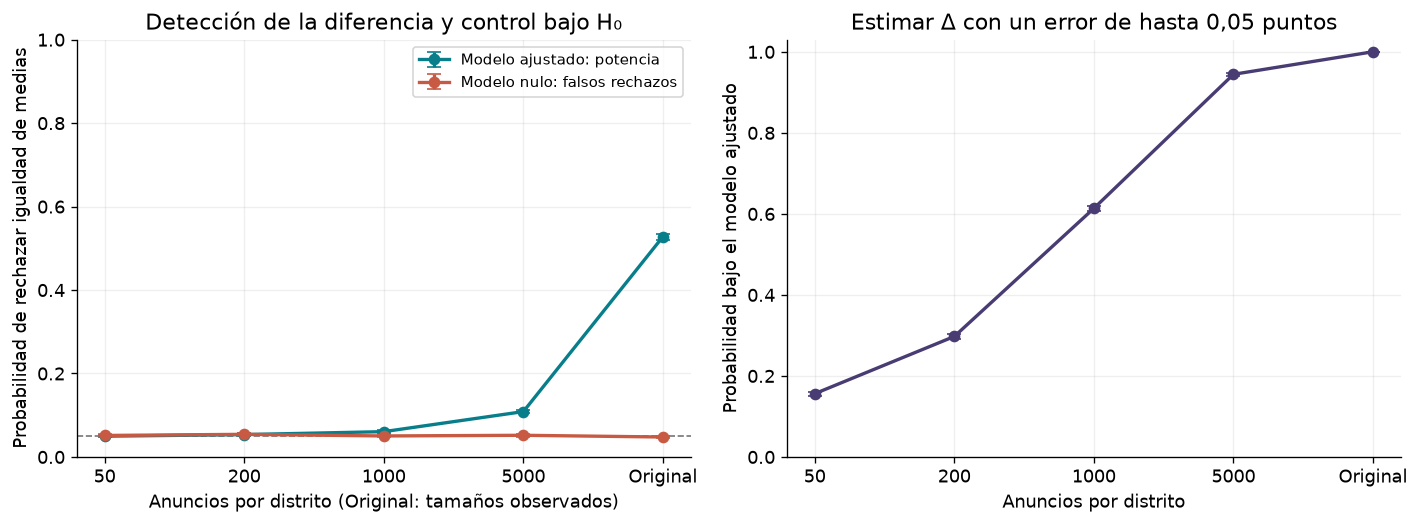

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ajustado = mc_tabla[mc_tabla['modelo'].eq('Ajustado')]
nulo = mc_tabla[mc_tabla['modelo'].eq('Nulo')]
x_pos = np.arange(len(escenarios))
for tabla, nombre, color in [(ajustado, 'Modelo ajustado: potencia', COLOR_M),
                             (nulo, 'Modelo nulo: falsos rechazos', COLOR_B)]:
    y = tabla['P_rechazo'].to_numpy()
    err = np.vstack([y-tabla['IC_MC_rechazo_inf'].to_numpy(),
                     tabla['IC_MC_rechazo_sup'].to_numpy()-y])
    axes[0].errorbar(x_pos, y, yerr=err, marker='o', color=color,
                     capsize=4, linewidth=2, label=nombre)
axes[0].axhline(ALPHA, color='#757575', linestyle='--', linewidth=1)
axes[0].set_xticks(x_pos, ajustado['escenario'])
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Anuncios por distrito (Original: tamaños observados)')
axes[0].set_ylabel('Probabilidad de rechazar igualdad de medias')
axes[0].set_title('Detección de la diferencia y control bajo H₀')
axes[0].legend(fontsize=9)
y = ajustado['P_error_hasta_005'].to_numpy()
axes[1].errorbar(x_pos, y, yerr=np.vstack([
    y-ajustado['IC_MC_precision_inf'].to_numpy(),
    ajustado['IC_MC_precision_sup'].to_numpy()-y]),
    marker='o', color='#493c73', capsize=4, linewidth=2)
axes[1].set_xticks(x_pos, ajustado['escenario'])
axes[1].set_ylim(0, 1.03)
axes[1].set_xlabel('Anuncios por distrito')
axes[1].set_ylabel('Probabilidad bajo el modelo ajustado')
axes[1].set_title('Estimar Δ con un error de hasta 0,05 puntos')
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUT / '03_mc_tamano_muestral.png', dpi=180)
plt.show()


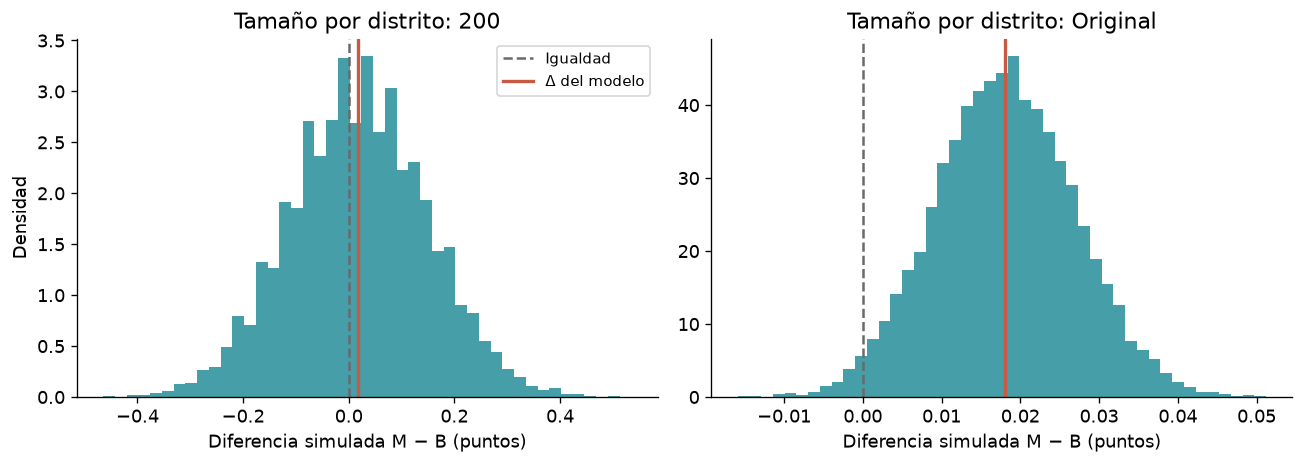

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, escenario in zip(axes, ['200', 'Original']):
    v = simulaciones[(escenario, 'Ajustado')]['delta_sim']
    ax.hist(v, bins=45, density=True, color=COLOR_M, alpha=0.75)
    ax.axvline(0, color='#6a6a6a', linestyle='--', label='Igualdad')
    ax.axvline(delta, color=COLOR_B, linewidth=2, label='Δ del modelo')
    ax.set_title(f'Tamaño por distrito: {escenario}')
    ax.set_xlabel('Diferencia simulada M − B (puntos)')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT / '04_mc_distribuciones.png', dpi=180)
plt.show()


## 7. Interpretación de Monte Carlo

En el modelo ajustado, `P_rechazo` es la **potencia simulada** de la prueba bilateral de Welch para una diferencia igual a la estimada. En el modelo nulo es la tasa de falsos rechazos. Es una evaluación del procedimiento bajo distribuciones especificadas, no una prueba adicional sobre los datos observados.

`P_error_hasta_005` responde: en muestreos repetidos del modelo, ¿qué fracción de diferencias estimadas queda a no más de 0,05 puntos de su valor poblacional dentro del modelo? `P_delta_positiva` describe la estabilidad del signo del estimador. Ninguna de estas cantidades es una probabilidad posterior sobre $\Delta$.

El número de anuncios por distrito controla la variación estadística. El número de realizaciones $R$ controla el error numérico con que aproximamos las probabilidades. Son cantidades distintas.


In [15]:
orig = ajustado[ajustado['escenario'].eq('Original')].iloc[0]
pequeno = ajustado[ajustado['escenario'].eq('200')].iloc[0]
display(Markdown(
    f'Con **200 anuncios por distrito**, la potencia simulada es '
    f'**{100*pequeno.P_rechazo:.2f}%** y la probabilidad de estimar la diferencia '
    f'con error de hasta 0,05 puntos es **{100*pequeno.P_error_hasta_005:.2f}%**. '
    f'Con los tamaños originales, estas cifras son **{100*orig.P_rechazo:.2f}%** '
    f'y **{100*orig.P_error_hasta_005:.2f}%**, respectivamente. '
    f'La probabilidad de obtener una diferencia positiva con tamaños originales '
    f'es **{100*orig.P_delta_positiva:.2f}%** bajo el modelo. '
    'La ganancia de precisión no modifica la magnitud poblacional fijada en la simulación.'))
display(Markdown(
    'Las tasas de falsos rechazos del escenario nulo van de '
    f'**{100*nulo.P_rechazo.min():.2f}% a {100*nulo.P_rechazo.max():.2f}%**. '
    'Se comparan con el nivel nominal del 5% y con sus intervalos de error Monte Carlo. '
    'Las pequeñas diferencias reflejan variación numérica y la aproximación de la prueba. '
    'Un 100% de éxitos simulados no garantiza una probabilidad poblacional de uno.'))


Con **200 anuncios por distrito**, la potencia simulada es **5.34%** y la probabilidad de estimar la diferencia con error de hasta 0,05 puntos es **29.73%**. Con los tamaños originales, estas cifras son **52.78%** y **100.00%**, respectivamente. La probabilidad de obtener una diferencia positiva con tamaños originales es **98.11%** bajo el modelo. La ganancia de precisión no modifica la magnitud poblacional fijada en la simulación.

Las tasas de falsos rechazos del escenario nulo van de **4.75% a 5.40%**. Se comparan con el nivel nominal del 5% y con sus intervalos de error Monte Carlo. Las pequeñas diferencias reflejan variación numérica y la aproximación de la prueba. Un 100% de éxitos simulados no garantiza una probabilidad poblacional de uno.

## 8. Conclusiones y limitaciones

Las siguientes conclusiones se generan desde los resultados, para evitar cifras copiadas a mano.


In [16]:
display(Markdown(
    f'1. Las medias observadas son **{mu_m:.4f} en Manhattan** y **{mu_b:.4f} en Brooklyn**. '
    f'El contraste es **{delta:.4f} puntos**. Esta comparación específica complementa '
    'la pregunta global de la Entrega 1.\n\n'
    f'2. El EE clásico de la diferencia es **{ee_delta:.6f}** y el bootstrap es '
    f'**{boot[:,2].std(ddof=1):.6f}**. Los intervalos del 95% son '
    f'**[{lo_delta:.4f}, {hi_delta:.4f}]** y **[{boot_lo:.4f}, {boot_hi:.4f}]**, '
    'respectivamente. Ambos métodos describen una diferencia pequeña bajo los supuestos adoptados.\n\n'
    f'3. En el modelo categórico ajustado, la potencia con tamaños originales es '
    f'**{100*orig.P_rechazo:.2f}%**. El tamaño muestral aumenta la precisión y la '
    'posibilidad de detectar una diferencia, aunque su magnitud permanezca pequeña.\n\n'
    '4. El resultado corresponde a anuncios calificados de esta fuente. No permite '
    'atribuir causalidad al distrito ni generalizar sin condiciones al mercado actual de NYC.'))


1. Las medias observadas son **3.2765 en Manhattan** y **3.2585 en Brooklyn**. El contraste es **0.0181 puntos**. Esta comparación específica complementa la pregunta global de la Entrega 1.

2. El EE clásico de la diferencia es **0.008875** y el bootstrap es **0.008844**. Los intervalos del 95% son **[0.0007, 0.0355]** y **[0.0006, 0.0354]**, respectivamente. Ambos métodos describen una diferencia pequeña bajo los supuestos adoptados.

3. En el modelo categórico ajustado, la potencia con tamaños originales es **52.78%**. El tamaño muestral aumenta la precisión y la posibilidad de detectar una diferencia, aunque su magnitud permanezca pequeña.

4. El resultado corresponde a anuncios calificados de esta fuente. No permite atribuir causalidad al distrito ni generalizar sin condiciones al mercado actual de NYC.

### 8.1 Sensibilidad descriptiva a las calificaciones faltantes

En los anuncios con distrito conocido faltan 140 calificaciones de Manhattan y 116 de Brooklyn. Como diagnóstico adicional, calculamos qué medias tendrían **todos los anuncios registrados de cada distrito** si esas calificaciones estuvieran entre 1 y 5. Este conjunto incluye anuncios sin calificación y, por tanto, amplía el conjunto de casos completos del análisis principal.

Si $S_g$ es la suma observada, $m_g$ el número de faltantes y $N_g$ el total registrado, la media completa queda entre $(S_g+m_g)/N_g$ y $(S_g+5m_g)/N_g$. Para la diferencia, el mínimo resta el máximo de Brooklyn al mínimo de Manhattan; el máximo invierte esos extremos.

Estas son **cotas deterministas**, no intervalos de confianza. Solo requieren que cada calificación faltante pueda tomar un valor de la escala 1–5. No corrigen anuncios ausentes de la fuente, distritos desconocidos ni problemas de medición.


In [17]:
filas_faltantes = []
for distrito in ['Manhattan', 'Brooklyn']:
    s = df.loc[df['neighbourhood_group'].eq(distrito), 'review_rate_number']
    total, faltantes = len(s), int(s.isna().sum())
    filas_faltantes.append([distrito, total, total-faltantes, faltantes,
        100*faltantes/total, (s.sum()+faltantes)/total,
        (s.sum()+5*faltantes)/total])
sensibilidad_faltantes = pd.DataFrame(filas_faltantes, columns=[
    'distrito', 'total_registrado', 'calificaciones_validas', 'faltantes',
    'porcentaje_faltante', 'media_minima', 'media_maxima']).set_index('distrito')
cota_delta_inf = (sensibilidad_faltantes.loc['Manhattan', 'media_minima']
                  - sensibilidad_faltantes.loc['Brooklyn', 'media_maxima'])
cota_delta_sup = (sensibilidad_faltantes.loc['Manhattan', 'media_maxima']
                  - sensibilidad_faltantes.loc['Brooklyn', 'media_minima'])
display(sensibilidad_faltantes)
display(Markdown(
    f'La diferencia descriptiva de todos los anuncios con distrito conocido queda entre '
    f'**{cota_delta_inf:.4f} y {cota_delta_sup:.4f} puntos** si los faltantes están en la escala 1–5. '
    'En estos datos, ni siquiera las asignaciones extremas de esas calificaciones invierten el signo. '
    'Esto no demuestra representatividad de la fuente ni elimina la incertidumbre por muestreo del análisis principal.'))


,total_registrado,calificaciones_validas,faltantes,porcentaje_faltante,media_minima,media_maxima
distrito,,,,,,
Manhattan,43558,43418,140,0.321411,3.269204,3.282061
Brooklyn,41631,41515,116,0.278639,3.252168,3.263313


La diferencia descriptiva de todos los anuncios con distrito conocido queda entre **0.0059 y 0.0299 puntos** si los faltantes están en la escala 1–5. En estos datos, ni siquiera las asignaciones extremas de esas calificaciones invierten el signo. Esto no demuestra representatividad de la fuente ni elimina la incertidumbre por muestreo del análisis principal.

### 8.2 Limitaciones que afectan la interpretación

- **Selección y ausencia de datos:** desconocemos el mecanismo de inclusión en Kaggle y el de las calificaciones faltantes. Eliminar solo los pares incompletos preserva los demás datos, pero no elimina sesgo de selección.
- **Calidad y procedencia:** la Entrega 1 detectó patrones inusuales en precio y calificaciones. Son motivos para limitar la generalización. No constituyen prueba de que los datos sean sintéticos.
- **Dependencia:** IDs distintos no garantizan independencia. Dependencia espacial, temporal o entre propiedades alteraría los EE e intervalos calculados.
- **Escala y agregación:** analizamos puntuaciones ordinales codificadas por anuncio, sin microdatos de huéspedes. Las medias dependen de la interpretación numérica de esa escala.
- **Modelo de simulación:** fijamos las probabilidades empíricas. Monte Carlo estudia comportamiento bajo esas distribuciones y no incorpora incertidumbre de parámetros o escenarios regulatorios y temporales.
- **Alcance del contraste:** Manhattan–Brooklyn cubre solo dos de los cinco distritos. Una diferencia pequeña aquí puede coexistir con diferencias entre otros distritos. La igualdad de medias no equivale a independencia de las variables.

**Mejoras respecto a la interpretación de la Entrega 1:** distinguimos igualdad de medias de independencia, evitamos reportar un p-valor redondeado como cero y expresamos las conclusiones como asociación condicionada al dataset. La V de Cramér y la diferencia de medias cuantifican aspectos distintos. Una asociación pequeña no demuestra ausencia de un efecto causal.


## 9. Exportación y comprobaciones

Se guardan tablas, réplicas, gráficos y un resumen estructurado para que la presentación use las mismas cifras. Las verificaciones contrastan dimensiones originales, limpieza, réplicas y referencias analíticas. Las tolerancias de simulación permiten variación numérica razonable y no sustituyen una revisión conceptual.


In [18]:
# Referencias independientes de SciPy para Welch y Wilson; no realizan bootstrap.
welch_referencia = stats.ttest_ind(M, K, equal_var=False)
ic_referencia = welch_referencia.confidence_interval(confidence_level=1-ALPHA)
assert np.allclose([delta/ee_delta, nu_delta],
                   [welch_referencia.statistic, welch_referencia.df])
assert np.allclose([lo_delta, hi_delta], [ic_referencia.low, ic_referencia.high])
eventos_control = simulaciones[('Original', 'Ajustado')]['rechazo_H0'].to_numpy()
ic_wilson_referencia = stats.binomtest(int(eventos_control.sum()), len(eventos_control)).proportion_ci(
    confidence_level=0.95, method='wilson')
assert np.allclose(intervalo_wilson(eventos_control)[2:],
                   [ic_wilson_referencia.low, ic_wilson_referencia.high])
assert boot.shape == (B, 3) and np.isfinite(boot).all()
assert np.allclose(boot[:, 2], boot[:, 0] - boot[:, 1])
assert np.all(np.abs(check_boot['error_relativo']) < 0.08)
assert np.all(np.abs(verificacion_mc['razon_sim_teoria'] - 1) < 0.05)
for (etiqueta, modelo), sim in simulaciones.items():
    assert len(sim) == R and np.isfinite(sim[['delta_sim', 'EE_sim']]).all().all()
    assert sim['delta_sim'].between(-4, 4).all()
    fila = mc_tabla[(mc_tabla['escenario'].eq(etiqueta)) & mc_tabla['modelo'].eq(modelo)].iloc[0]
    verdad = delta if modelo == 'Ajustado' else 0.0
    ee_centro = sim['delta_sim'].std(ddof=1) / np.sqrt(R)
    assert abs(sim['delta_sim'].mean()-verdad) < 5*ee_centro

resumen_distritos.to_csv(OUT / 'resumen_distritos.csv')
comparacion.to_csv(OUT / 'comparacion_estimacion.csv')
estabilidad_boot.to_csv(OUT / 'estabilidad_bootstrap.csv', index=False)
mc_tabla.to_csv(OUT / 'monte_carlo_escenarios.csv', index=False)
convergencia_mc.to_csv(OUT / 'convergencia_monte_carlo.csv', index=False)
probabilidades.to_csv(OUT / 'probabilidades_modelo.csv', index=False)
sensibilidad.to_csv(OUT / 'sensibilidad_umbrales.csv', index=False)
sensibilidad_faltantes.to_csv(OUT / 'sensibilidad_faltantes.csv')
np.savez_compressed(OUT / 'replicas_simulacion.npz', bootstrap=boot,
    **{f'mc_{e}_{m}': s['delta_sim'].to_numpy() for (e,m),s in simulaciones.items()})

hist_y, hist_bordes = np.histogram(boot[:, 2], bins=30, density=True)
densidades_medias = []
for j, distrito in enumerate(['Manhattan', 'Brooklyn']):
    densidad, bordes = np.histogram(boot[:, j], bins=30, density=True)
    densidades_medias.append({'distrito': distrito,
        'x': ((bordes[:-1]+bordes[1:])/2).tolist(), 'y': densidad.tolist()})
resumen = {'dataset_sha256': sha256, 'versiones': versiones,
    'semillas': {'bootstrap': SEED_BOOT, 'monte_carlo': SEED_MC},
    'B': B, 'R': R, 'alpha': ALPHA, 'tolerancia_precision': TOL_PRECISION,
    'auditoria': auditoria, 'n_pares_cinco_distritos': len(pares),
    'estimacion': comparacion.reset_index().to_dict(orient='records'),
    'monte_carlo': mc_tabla.to_dict(orient='records'),
    'estabilidad_bootstrap': estabilidad_boot.to_dict(orient='records'),
    'convergencia_mc': convergencia_mc.to_dict(orient='records'),
    'probabilidades': probabilidades.to_dict(orient='records'),
    'sensibilidad_faltantes': sensibilidad_faltantes.reset_index().to_dict(orient='records'),
    'cotas_delta_faltantes': [float(cota_delta_inf), float(cota_delta_sup)],
    'bootstrap_medias_densidad': densidades_medias,
    'bootstrap_densidad': {'x': ((hist_bordes[:-1]+hist_bordes[1:])/2).tolist(),
                          'y': hist_y.tolist()}}
(OUT / 'resumen_resultados.json').write_text(json.dumps(resumen, ensure_ascii=False, indent=2), encoding='utf-8')
print('Comprobaciones aprobadas. Resultados guardados en:', OUT.name)


Comprobaciones aprobadas. Resultados guardados en: resultados


## Referencias

1. Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*. The Annals of Statistics, 7(1), 1–26. [DOI: 10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552).
2. Shalizi, C. R. (2018). *Simulation for Inference I — The Bootstrap*. Carnegie Mellon University, notas docentes. [Documento](https://stat.cmu.edu/~cshalizi/dst/18/lectures/18/lecture-18.html).
3. National Institute of Standards and Technology. *Monte Carlo Tool*. [Descripción institucional](https://www.nist.gov/services-resources/software/monte-carlo-tool).
4. NumPy. *numpy.random.Generator.multinomial*. [Documentación oficial](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.multinomial.html).
5. Airbnb Open Data (NYC), versión 1. [Kaggle](https://www.kaggle.com/datasets/arianazmoudeh/airbnbopendata). Fuente compartida con la Entrega 1.
6. INF280, UTFSM. *Laboratorio 2 — Simulación e Inferencia*. Enunciado entregado al grupo, 28 de septiembre de 2026.
7. SciPy. *scipy.stats.ttest_ind*. [Documentación oficial de la prueba de Welch](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html).
8. NIST/SEMATECH. *7.2.4.1. Confidence intervals*. [Intervalo de Wilson para proporciones](https://www.itl.nist.gov/div898/handbook/prc/section2/prc241.htm).

**Ejecución:** abrir este archivo en Jupyter o VS Code, reiniciar el kernel y ejecutar todas las celdas en orden. En Colab, subir también el CSV y situarlo en `data/Airbnb_Open_Data.csv`. El archivo `requirements.txt` contiene las versiones utilizadas para esta ejecución.
